In [1]:
from google.colab import files
uploaded_files = files.upload()

Saving Confessions of a Rotten Girl (1).png to Confessions of a Rotten Girl (1) (4).png


In [2]:
import PIL
from PIL import Image
import numpy as np

path = 'Confessions of a Rotten Girl (1).png'
image = Image.open(path)

In [3]:
#image

In [4]:
#Code adapted from stackoverflow
def linear_sRGB(c):
    if c <= 0.04045:
        return c / 12.92
    else:
        return pow((c + 0.055) / 1.055, 2.4)

def sRGB_to_XYZn(r, g, b):
    Rlin = linear_sRGB(r / 255.0)
    Glin = linear_sRGB(g / 255.0)
    Blin = linear_sRGB(b / 255.0)
    Xn = Rlin * 0.4124 + Glin * 0.3576 + Blin * 0.1805
    Yn = Rlin * 0.2126 + Glin * 0.7152 + Blin * 0.0722
    Zn = Rlin * 0.0193 + Glin * 0.1192 + Blin * 0.9505
    return Xn, Yn, Zn

def gamma_sRGB(c):
    if c <= 0.0031308:
        return 12.92 * c
    else:
        return 1.055 * pow(c, 1/2.4) - 0.055

def XYZn_to_sRGB(Xn, Yn, Zn):
    Rlin = Xn * 3.2406255 + Yn *-1.5372080 + Zn *-0.4986286
    Glin = Xn *-0.9689307 + Yn * 1.8757561 + Zn * 0.0415175
    Blin = Xn * 0.0557101 + Yn *-0.2040211 + Zn * 1.0569959
    R = round(255 * gamma_sRGB(Rlin))
    G = round(255 * gamma_sRGB(Glin))
    B = round(255 * gamma_sRGB(Blin))
    return [R, G, B]

def linear_AdobeRGB(c):
    if c <= 0.0:
        return 0.0
    return pow(c, 2.19921875)

def AdobeRGB_to_XYZn(R, G, B):
    Rlin = linear_AdobeRGB(R / 255.0)
    Glin = linear_AdobeRGB(G / 255.0)
    Blin = linear_AdobeRGB(B / 255.0)
    Xn = Rlin * 0.57667 + Glin * 0.18556 + Blin * 0.18823
    Yn = Rlin * 0.29734 + Glin * 0.62736 + Blin * 0.07529
    Zn = Rlin * 0.02703 + Glin * 0.07069 + Blin * 0.99134
    return [Xn, Yn, Zn]

def gamma_AdobeRGB(c):
    if c <= 0.0:
        return 0.0
    return pow(c, 1/2.19921875)

def XYZn_to_AdobeRGB(Xn, Yn, Zn):
    Rlin = Xn * 2.04159 + Yn *-0.56501 + Zn *-0.34473
    Glin = Xn *-0.96924 + Yn * 1.87597 + Zn * 0.04156
    Blin = Xn * 0.01344 + Yn *-0.11836 + Zn * 1.01517
    R = round(255 * gamma_AdobeRGB(Rlin))
    G = round(255 * gamma_AdobeRGB(Glin))
    B = round(255 * gamma_AdobeRGB(Blin))
    return [R, G, B]

def sRGB_to_AdobeRGB(r, g, b):
    R, G, B = sRGB_to_XYZn(r, g, b)
    return XYZn_to_AdobeRGB(R, G, B)

def AdobeRGB_to_sRGB(R, G, B):
    r, g, b = AdobeRGB_to_XYZn(R, G, B)
    return XYZn_to_sRGB(r, g, b)

In [5]:
#color in hexadecimal
def convert_color_to_number_array(color):
  red = color[1:3]
  green = color[3:5]
  blue = color[5:7]
  return [convert_color_to_number(red), convert_color_to_number(green), convert_color_to_number(blue)]

def convert_color_to_number(color):
  num1 = convert_character_to_number(color[0])
  num2 = convert_character_to_number(color[1])
  return num1 * 16 + num2

def convert_character_to_number(char):
  match char.lower():
    case "a":
      return 10
    case "b":
      return 11
    case "c":
      return 12
    case "d":
      return 13
    case "e":
      return 14
    case "f":
      return 15
    case _:
      return int(char)

convert_color_to_number_array("#ABCDEF")

[171, 205, 239]

In [6]:
colors_hex = [0] * 64
colors_hex[0]  = "#000000" # Black
colors_hex[1]  = "#3c3c3c" # Dary Gray
colors_hex[2]  = "#787878" # Gray
colors_hex[3]  = "#aaaaaa" # Medium Gray (#aaaaaa)
colors_hex[4]  = "#d2d2d2" # Light Gray
colors_hex[5]  = "#ffffff" # White
colors_hex[6]  = "#600018" # Deep Red
colors_hex[7]  = "#a50e1e" # Dark Red
colors_hex[8]  = "#ed1c24" # Red
colors_hex[9]  = "#fa8072" # Light Red
colors_hex[10] = "#e45c1a" # Dark Orange
colors_hex[11] = "#ff7f27" # Orange
colors_hex[12] = "#f6aa09" # Gold
colors_hex[13] = "#f9dd3b" # Yellow
colors_hex[14] = "#fffabc" # Light Yellow
colors_hex[15] = "#9C8431" # Dark Goldenrod
colors_hex[16] = "#C5AD31" # Goldenrod
colors_hex[17] = "#E8D45F" # Light Goldenrod
colors_hex[18] = "#4A6B3A" # Dark Olive
colors_hex[19] = "#5A944A" # Olive
colors_hex[20] = "#84C573" # Light Olive
colors_hex[21] = "#0EB968" # Dark Green
colors_hex[22] = "#13E67B" # Green
colors_hex[23] = "#87FF5E" # Light Green
colors_hex[24] = "#0C816E" # Dark Teal
colors_hex[25] = "#10AEA6" # Teal
colors_hex[26] = "#13E1BE" # Light Teal
colors_hex[27] = "#0F799F" # Dark Cyan
colors_hex[28] = "#60F7F2" # Cyan
colors_hex[29] = "#BBFAF2" # Light Cyan
colors_hex[30] = "#28509E" # Dark Blue
colors_hex[31] = "#4093E4" # Blue
colors_hex[32] = "#7DC7FF" # Light Blue
colors_hex[33] = "#4D31B8" # Dark Indigo
colors_hex[34] = "#6B50F6" # Indigo
colors_hex[35] = "#99B1FB" # Light Indigo
colors_hex[36] = "#45467C" # Dark Slate Blue
colors_hex[37] = "#7A71C4" # Slate Blue
colors_hex[38] = "#B5AEF1" # Light Slate Blue
colors_hex[39] = "#780C99" # Dark Purple
colors_hex[40] = "#AA38B9" # Purple
colors_hex[41] = "#E09FF9" # Light Purple
colors_hex[42] = "#CB007A" # Dark Pink
colors_hex[43] = "#EC1F80" # Pink
colors_hex[44] = "#F38DA9" # Light Pink
colors_hex[45] = "#9B5249" # Dark Peach
colors_hex[46] = "#D18078" # Peach
colors_hex[47] = "#FAB6A4" # Light Peach
colors_hex[48] = "#684634" # Dark Brown
colors_hex[49] = "#95682A" # Brown
colors_hex[50] = "#DBA463" # Light Brown
colors_hex[51] = "#7B6352" # Dark Tan
colors_hex[52] = "#9C846B" # Tan
colors_hex[53] = "#D6B594" # Light Tan
colors_hex[54] = "#D18051" # Dark Beige
colors_hex[55] = "#F8B277" # Beige
colors_hex[56] = "#FFC5A5" # Light Beige
colors_hex[57] = "#6D643F" # Dark Stone
colors_hex[58] = "#948C6B" # Stone
colors_hex[59] = "#CDC59E" # Light Stone
colors_hex[60] = "#333941" # Dark Slate
colors_hex[61] = "#6D758D" # Slate
colors_hex[62] = "#B3B9D1" # Light Slate
colors_hex[63] = "#F8F4F0" # Transparent

srgb_palette = [convert_color_to_number_array(color_hex) for color_hex in colors_hex]
#print(srgb_palette)
adobe_palette = [sRGB_to_AdobeRGB(color[0], color[1], color[2]) for color in srgb_palette]
#print(adobe_palette)

setter_palette = adobe_palette.copy()

[[0, 0, 0], [60, 60, 60], [120, 120, 120], [170, 170, 170], [210, 210, 210], [255, 255, 255], [96, 0, 24], [165, 14, 30], [237, 28, 36], [250, 128, 114], [228, 92, 26], [255, 127, 39], [246, 170, 9], [249, 221, 59], [255, 250, 188], [156, 132, 49], [197, 173, 49], [232, 212, 95], [74, 107, 58], [90, 148, 74], [132, 197, 115], [14, 185, 104], [19, 230, 123], [135, 255, 94], [12, 129, 110], [16, 174, 166], [19, 225, 190], [15, 121, 159], [96, 247, 242], [187, 250, 242], [40, 80, 158], [64, 147, 228], [125, 199, 255], [77, 49, 184], [107, 80, 246], [153, 177, 251], [69, 70, 124], [122, 113, 196], [181, 174, 241], [120, 12, 153], [170, 56, 185], [224, 159, 249], [203, 0, 122], [236, 31, 128], [243, 141, 169], [155, 82, 73], [209, 128, 120], [250, 182, 164], [104, 70, 52], [149, 104, 42], [219, 164, 99], [123, 99, 82], [156, 132, 107], [214, 181, 148], [209, 128, 81], [248, 178, 119], [255, 197, 165], [109, 100, 63], [148, 140, 107], [205, 197, 158], [51, 57, 65], [109, 117, 141], [179, 185

In [7]:
def get_closest_color_rgb(r, g, b):
  r = int(r)
  g = int(g)
  b = int(b)
  min_dist = np.inf
  for index in range(len(adobe_palette)):
    pr, pg, pb = adobe_palette[index]
    dist = np.sqrt((pr - r) ** 2 + (pg - g) ** 2 + (pb - b) ** 2)
    if dist < min_dist:
      min_dist = dist
      closest_color = setter_palette[index]
  return closest_color

get_closest_color_rgb(235, 234, 243)

[247, 244, 240]

In [8]:
h = 256
w = h

resized_image = PIL.ImageOps.contain(image, (w, h))
image_arr = np.asarray(resized_image, dtype = "float64")
print(image_arr.shape)

(256, 256, 4)


In [9]:
#resized_image

In [10]:
def diffuse_error(image_arr, kernel, row_origin, col_origin, row_image, col_image, error):
  for row_kernel in range(len(kernel)):
    row_diff = row_kernel - row_origin
    row_new = row_image + row_diff
    if row_new < 0 or row_new >= h:
      continue
    for col_kernel in range(len(kernel[row_kernel])):
      col_diff = col_kernel - col_origin
      col_new = col_image + col_diff
      if col_new < 0 or col_new >= w:
        continue
      image_arr[row_new][col_new] = [image_arr[row_new][col_new][i] + error[i] * kernel[row_kernel][col_kernel] for i in range(3)]

def diffuse_error_arr(image_arr, kernel, row_origin, col_origin):
  dithered = [[0 for x in range(w)] for y in range(h)]
  image_arr_copy = [[sRGB_to_AdobeRGB(color[0], color[1], color[2]) for color in row] for row in image_arr]
  for row in range(h):
    for col in range(w):
      r, g, b = image_arr_copy[row][col]
      dithered[row][col] = get_closest_color_rgb(r, g, b)
      error = [image_arr_copy[row][col][i] - dithered[row][col][i] for i in range(3)]
      diffuse_error(image_arr_copy, kernel, row_origin, col_origin, row, col, error)
  return dithered

kernel_floyd_steinberg = [
    [   0,    0, 7/16],
    [3/16, 5/16, 1/16]
]
kernel_min_avg_err = [
    [   0,    0,    0, 7/48, 5/48],
    [3/48, 5/48, 7/48, 5/48, 3/48],
    [1/48, 3/48, 5/48, 3/48, 1/48]
]

def AdobeRGB_to_sRGB_palette(R, G, B):
  return srgb_palette[adobe_palette.index([R, G, B])]

dithered_floyd = diffuse_error_arr(image_arr, kernel_floyd_steinberg, 0, 1)
#print(dithered_floyd)
closest_image_arr_rgb = [[AdobeRGB_to_sRGB_palette(color[0], color[1], color[2]) for color in row] for row in dithered_floyd]
#print(closest_image_arr_rgb)
closest_image_rgb_floyd = Image.fromarray(np.uint8(closest_image_arr_rgb))
#print()

dithered_mae = diffuse_error_arr(image_arr, kernel_min_avg_err, 0, 2)
#print(dithered_mae)
closest_image_arr_rgb = [[AdobeRGB_to_sRGB_palette(color[0], color[1], color[2]) for color in row] for row in dithered_mae]
#print(closest_image_arr_rgb)
closest_image_rgb_mae = Image.fromarray(np.uint8(closest_image_arr_rgb))
#print()

#print(dithered_floyd == dithered_mae)

[[[247, 244, 240], [247, 244, 240], [247, 244, 240], [247, 244, 240], [247, 244, 240], [247, 244, 240], [206, 250, 242], [247, 244, 240], [247, 244, 240], [247, 244, 240], [247, 244, 240], [247, 244, 240], [206, 250, 242], [247, 244, 240], [247, 244, 240], [247, 244, 240], [247, 244, 240], [247, 244, 240], [247, 244, 240], [247, 244, 240], [247, 244, 240], [247, 244, 240], [209, 209, 209], [111, 116, 139], [247, 244, 240], [247, 244, 240], [247, 244, 240], [247, 244, 240], [206, 250, 242], [247, 244, 240], [247, 244, 240], [247, 244, 240], [247, 244, 240], [206, 250, 242], [247, 244, 240], [247, 244, 240], [247, 244, 240], [247, 244, 240], [206, 250, 242], [247, 244, 240], [247, 244, 240], [247, 244, 240], [247, 244, 240], [206, 250, 242], [247, 244, 240], [247, 244, 240], [247, 244, 240], [206, 250, 242], [148, 131, 108], [56, 60, 67], [83, 0, 30], [138, 83, 75], [141, 22, 35], [141, 22, 35], [138, 83, 75], [141, 22, 35], [56, 60, 67], [148, 131, 108], [255, 255, 255], [247, 244, 240]

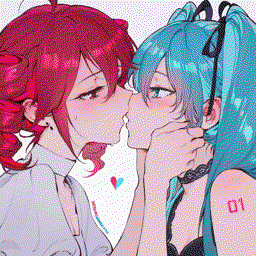

In [11]:
closest_image_rgb_floyd

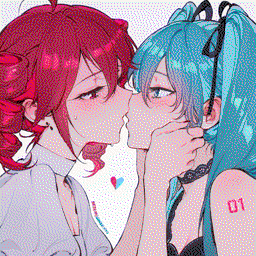

In [12]:
closest_image_rgb_mae

In [13]:
dithered = dithered_mae
closest_image_rgb = closest_image_rgb_mae

In [14]:
def count_colored_pixels(image_arr):
  colored_pixels = 0
  for row in range(h):
    for col in range(w):
      pixel = image_arr[row][col]
      if pixel != srgb_palette[63]:
        colored_pixels += 1
  return colored_pixels

#print(image_arr.shape[0] ** 2)
#print(count_colored_pixels(closest_image_arr_rgb))
#print(count_colored_pixels(closest_image_arr_rgb) / image_arr.shape[0] ** 2)

65536
60574
0.924285888671875


In [15]:
def turn_image_to_palette_indices(image_arr):
  indices_arr = [[0 for x in range(w)] for y in range(h)]
  for row in range(h):
    for col in range(w):
      indices_arr[row][col] = srgb_palette.index(image_arr[row][col])
  return indices_arr

def print_2d_arr(arr):
  for row in range(len(arr)):
    for col in range(len(arr[0])):
      if arr[row][col] == -1:
        print("  ", end = ', ')
      else:
        print("{:2d}".format(arr[row][col]), end = ', ')
    print()
    print()

index_arr = turn_image_to_palette_indices(closest_image_arr_rgb)
#print_2d_arr(index_arr)

63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63,  4, 61,  4, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 61,  1,  7,  7,  7, 45,  7,  7,  1, 61, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63,  5, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63,  4, 36, 60,  0,  1,  4, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63,  4,  4,  4, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 

In [16]:
import math

def get_square(index_arr, square_length = 8, square_row = 0, square_col = 0):
  nth_square = [[0 for _ in range(square_length)] for _ in range(square_length)]
  for i in range(square_length):
    row = square_row * square_length + i
    for j in range(square_length):
      col = square_col * square_length + j
      nth_square[i][j] = index_arr[row][col]
  return nth_square

def get_nth_square(index_arr, square_length = 8, n = 0):
  image_length = len(index_arr[0])
  squares_per_side = math.ceil(image_length / square_length)
  square_row = int(n / squares_per_side)
  square_col = n % squares_per_side
  return get_square(index_arr, square_length, square_row, square_col)

#print_2d_arr(get_square(index_arr, 8, 15, 0))

45,  7,  7, 42, 43, 43,  9, 43, 

 7, 42, 45, 43, 43, 43,  8,  8, 

 7, 45, 43, 43, 10, 43,  8, 45, 

45,  7,  7, 45, 43, 43, 43, 43, 

 7, 42,  7, 43, 43, 45, 45,  7, 

45, 45,  7,  7,  7,  7,  7, 45, 

 7, 45, 39, 45, 45,  7,  7, 48, 

 7,  6,  6,  6,  6,  7, 39,  7, 



In [17]:
def get_grid_outline(square_length = 8):
  grid_outline = [[0 for _ in range(w)] for _ in range(h)]
  for row in range(h):
    for col in range(w):
      if row % square_length == 0 or col % square_length == 0:
        grid_outline[row][col] = index_arr[row][col]
      else:
        grid_outline[row][col] = -1
  return grid_outline

#print_2d_arr(get_grid_outline(8))

63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63,  4, 61,  4, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 61,  1,  7,  7,  7, 45,  7,  7,  1, 61, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63,  5, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63,  4, 36, 60,  0,  1,  4, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63,  4,  4,  4, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 

In [18]:
def scale_img_arr(image_arr, scale):
  new_image = [[0 for x in range(w*scale)] for y in range(h*scale)]
  for row in range(h*scale):
    for col in range(w*scale):
      new_image[row][col] = image_arr[int(row / scale)][int(col / scale)]
  return new_image

scaled_img_arr = scale_img_arr(closest_image_arr_rgb, 2)
scaled_img = Image.fromarray(np.uint8(scaled_img_arr))

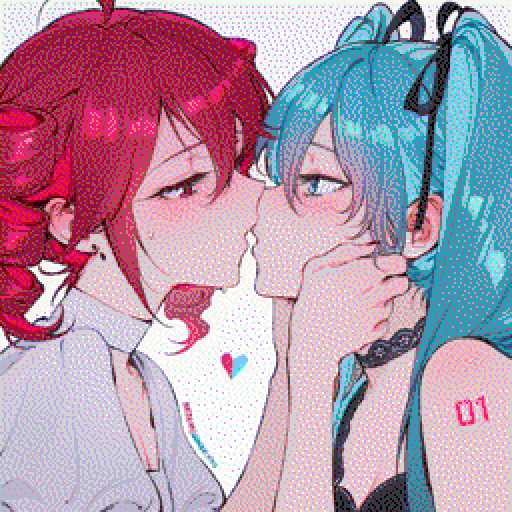

In [19]:
scaled_img